#### **imports**

In [ ]:
import xarray as xr
import numpy as np
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

### **loading in data**

In [ ]:
# getting directory for the result batches nc files 
parent_dir = Path.cwd() / "climate_experiments" 

# initializing dictionary for folder file counts to ensure each folder (differentiated as folder paths) has same number of folder items 
folder_file_counts = {}

# going thru directory to find any folders that start with result_batches (by the glob) & going thru it alphabetically (by the sorted)
for run_folder in sorted(parent_dir.glob("results_batches_*")):
    # is_dir() to ensure that result_batches is actually a folder, not like a nc file or something idk 
    if run_folder.is_dir():
        # turning all the nc files in that folder into a list 
        nc_files = list(run_folder.glob("*.nc"))
        # if there are actually files in the folder
        if nc_files: 
            # count number of files in the folder and store that in the dictionary
            folder_file_counts[run_folder] = len(nc_files)

# error handling if all the folders are empty 
if not folder_file_counts:
    raise ValueError("no nc files in the folder!")


# finding max number of file counts (should be 56/57) -- complete run length
dynamic_expected = max(folder_file_counts.values())
print(f"max is {dynamic_expected} files")


# initializie list that will hold the arrays from every run 
all_runs_data = []

# going through each folder and looking at the files and the count of the files in the folder
for run_folder, count in folder_file_counts.items():

    # if the count of the files in the run folder does not equal 56/57 
    if count != dynamic_expected:
        print(f"skip{run_folder.name} bc only {count} files, expected {dynamic_expected}")
        # keep going to the next folder and don't save the folder that doesn't have right amount of files 
        continue
    
    # saving the nc files in chrnological order (via sorted)
    nc_files = sorted(list(run_folder.glob("*.nc")))
    # opening the files in the folder
        # concat_dim = yr_combo --> creates new dimension to stack all the arrays tg 
        # combine = nested --> just stack in the order that files are alr in since alr sorted (computationally more efficient)
    run_ds = xr.open_mfdataset(nc_files, concat_dim='yr_combo', combine='nested')
    
    # Extract values and average the 'sample' dimension (axis=1)
    run_data = run_ds['ig_heatmaps'].values
    run_mean_samples = np.nanmean(np.abs(run_data), axis=1)
    
    all_runs_data.append(run_mean_samples)


# --- STEP 3: Stack and aggregate ---
if not all_runs_data:
    raise ValueError("Error: No valid runs left to stack.")

# Stack the standardized arrays
master_phi_matrix = np.stack(all_runs_data)
print(f"Success! Master matrix stacked with shape: {master_phi_matrix.shape}")

# Final aggregation for the heatmap: (yr_combos, features)
mean_importance = np.nanmean(master_phi_matrix, axis=(0, 2, 3))

# first dimension = number of result batches, second = year combos, third = long, fourth = lat, fifth = variables

Auto-detected complete run size: 56 files.
Skipping results_batches_Caroline_1 -> Found 46 files, expected 56.
Skipping results_batches_sophiekim_3 -> Found 2 files, expected 56.
Success! Master matrix stacked with shape: (5, 56, 144, 73, 7)


In [ ]:


def plot_ranked_matrices_single_global_scale(phi_matrix, yr_combos_df, var_names, scenario_id="ssp119"):
    """
    Plots the Most, Second Most, and Least important variables side-by-side in one row.
    - Uses a single, globally scaled colorbar based on the completeness property.
    - Scientific notation rounded to 2 decimal places.
    - Y-axis labels are rotated to read horizontally left-to-right.
    """
    
    # 1. Calculate Custom Colorbar Bounds (Completeness Property)
    num_runs = phi_matrix.shape[0]
    num_combos = phi_matrix.shape[1]
    num_lon = phi_matrix.shape[2]
    num_lat = phi_matrix.shape[3]
    num_vars = phi_matrix.shape[4]
    
    total_phi_sum = np.nansum(np.abs(phi_matrix))
    cbar_bound = total_phi_sum / (num_runs * num_combos * num_vars * num_lon * num_lat)
    
    # 2. Aggregate to 2D (yr_combos, vars)
    mean_importance = np.nanmean(np.abs(phi_matrix), axis=(0, 2, 3))
    
    # 3. Sort variables by importance AND get their sorted values
    sorted_indices = np.argsort(mean_importance, axis=1)
    sorted_values = np.sort(mean_importance, axis=1)
    
    # Define the rankings to loop through safely ordered
    rank_keys = ["Most Important", "Second Most Important", "Least Important"]
    rank_data = [
        (sorted_indices[:, -1], sorted_values[:, -1]), 
        (sorted_indices[:, -2], sorted_values[:, -2]), 
        (sorted_indices[:, 0],  sorted_values[:, 0])   
    ]
    
    # Pre-calculate the matrix grid structure
    all_years = sorted(list(set(yr_combos_df['early'].unique()) | set(yr_combos_df['late'].unique())))
    labels = [f"{int(y)}-{int(y)+9}" for y in all_years]
    
    # --- PLOTTING SETUP ---
    fig, axes = plt.subplots(1, 3, figsize=(26, 11))
    
    # Create a dedicated axis for the single global colorbar at the bottom center
    # [left, bottom, width, height]
    cbar_ax = fig.add_axes([0.35, 0.06, 0.3, 0.025]) 
    
    for i, rank_title in enumerate(rank_keys):
        rank_indices, rank_values = rank_data[i]
        ax = axes[i]
        
        # Format strings to scientific notation with 2 decimal places
        combined_labels = [
            f"{var_names[idx]}\n{val:.2e}" 
            for idx, val in zip(rank_indices, rank_values)
        ]
        
        df = yr_combos_df.copy()
        df['importance_val'] = rank_values  
        df['text_label'] = combined_labels  
        
        color_matrix = df.pivot_table(index='early', columns='late', values='importance_val', aggfunc='first')
        color_matrix = color_matrix.reindex(index=all_years, columns=all_years)
        
        text_matrix = df.pivot_table(index='early', columns='late', values='text_label', aggfunc='first')
        text_matrix = text_matrix.reindex(index=all_years, columns=all_years).fillna("")
        
        mask = np.tril(np.ones_like(color_matrix, dtype=bool), k=0)
        
        sns.heatmap(
            color_matrix,
            mask=mask,
            cmap='viridis', 
            annot=text_matrix.values, 
            fmt="",                   
            square=True,
            linewidths=.5,
            vmin=0,           # Global min
            vmax=cbar_bound,  # Global max from completeness bound
            ax=ax,
            annot_kws={"size": 8},
            cbar=(i == 0),        # Only draw the colorbar on the very first loop iteration
            cbar_ax=cbar_ax if i == 0 else None, 
            cbar_kws={"orientation": "horizontal"} if i == 0 else None
        )
        
        # Grid Layout & Label Formatting
        ax.xaxis.tick_top()
        ax.xaxis.set_label_position('top')
        
        ax.set_xticklabels(labels, rotation=45, ha='left', fontsize=10, fontweight='bold')
        # Rotation=0 forces horizontal early period labels
        ax.set_yticklabels(labels, rotation=0, fontsize=10, fontweight='bold')
        
        ax.set_xlabel("Late 10-Year Period", fontsize=12, fontweight='bold', labelpad=12)
        ax.set_ylabel("Early 10-Year Period", fontsize=12, fontweight='bold')
        ax.set_title(rank_title, fontsize=16, fontweight='bold', pad=25)

    # --- GLOBAL COLORBAR FORMATTING ---
    # Apply styling directly to the dedicated cbar_ax we created
    cbar_ax.xaxis.set_major_formatter(plt.FormatStrFormatter('%.2e'))
    cbar_ax.tick_params(labelsize=11)
    for tick in cbar_ax.get_xticklabels():
        tick.set_fontweight('bold')
    cbar_ax.set_xlabel("Mean Integrated Gradients ($\phi$)", fontsize=13, fontweight='bold', labelpad=10)
        
    plt.suptitle(f"Ranked Feature Matrices: {scenario_id.upper()}", fontsize=22, fontweight='bold', y=1.02)
    
    # tight_layout rect leaves the bottom 12% of the figure empty so it doesn't crush our custom colorbar
    plt.tight_layout(rect=[0, 0.12, 1, 1]) 
    plt.show()

In [ ]:


# 1. Point to ONE of your successful run folders (any folder that has the full 56 files)
# Make sure to update the scenario or user name if your folder is named differently
sample_folder = Path.cwd() / "climate_experiments" / "results_batches_sophiekim_1" 

# 2. Get the sorted list of files EXACTLY as the previous script did
nc_files = sorted(list(sample_folder.glob("*.nc")))

data = []

# 3. Loop through the files and extract the early/late years
for idx, filepath in enumerate(nc_files):
    
    # .stem removes the folder path and the .nc extension
    # Example: "res_ssp119_2020_2030"
    filename = filepath.stem 
    
    # Split the string by the underscores
    # Example: ['res', 'ssp119', '2020', '2030']
    parts = filename.split('_')
    
    # The second to last part is the early year, the last part is the late year
    early_yr = int(parts[-2])
    late_yr = int(parts[-1])
    
    # Append to our list
    data.append({
        'combo_idx': idx,
        'early': early_yr,
        'late': late_yr
    })

# 4. Convert to DataFrame
my_yr_combos_df = pd.DataFrame(data)

# Print the first few rows to verify it worked!
print(my_yr_combos_df.head())

   combo_idx  early  late
0          0   2015  2025
1          1   2015  2035
2          2   2015  2045
3          3   2015  2055
4          4   2015  2065


In [43]:
# 1. Define your 7 climate variables as a list of strings
# (Make sure these are in the exact same order they appear in axis 4 of your NetCDF files!)
my_variables = ["tas", "tasmax", "tasmin", "pr", "psl", "sfcWind", "mrsos"] # got order from the get_cnn_tensors file bc that is when X_data was prepped


# Create your master translation dictionary
variable_dictionary = {
    "tas": "Mean Surface\nTemp",
    "tasmax": "Max Surface\nTemp",
    "tasmin": "Min Surface\nTemp",
    "pr": "Precipitation",
    "psl": "Sea Level\nPressure",
    "sfcWind": "Surface Wind\nSpeed",
    "mrsos": "Upper Soil\nMoisture"
}


# Your original raw list (must match the order in the NetCDF files/CNN tensor)
raw_variables = ["tas", "tasmax", "tasmin", "pr", "psl", "sfcWind", "mrsos"]

# Create the translated list
readable_variables = [variable_dictionary[var] for var in raw_variables]

print(readable_variables)
# Output: ['Mean Surface Temp', 'Max Surface Temp', 'Min Surface Temp', ...]


['Mean Surface\nTemp', 'Max Surface\nTemp', 'Min Surface\nTemp', 'Precipitation', 'Sea Level\nPressure', 'Surface Wind\nSpeed', 'Upper Soil\nMoisture']


/var/folders/v1/c8q_17915_v735dr_k_2fb7w0000gn/T/ipykernel_26949/875076779.py:112: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0.12, 1, 1])


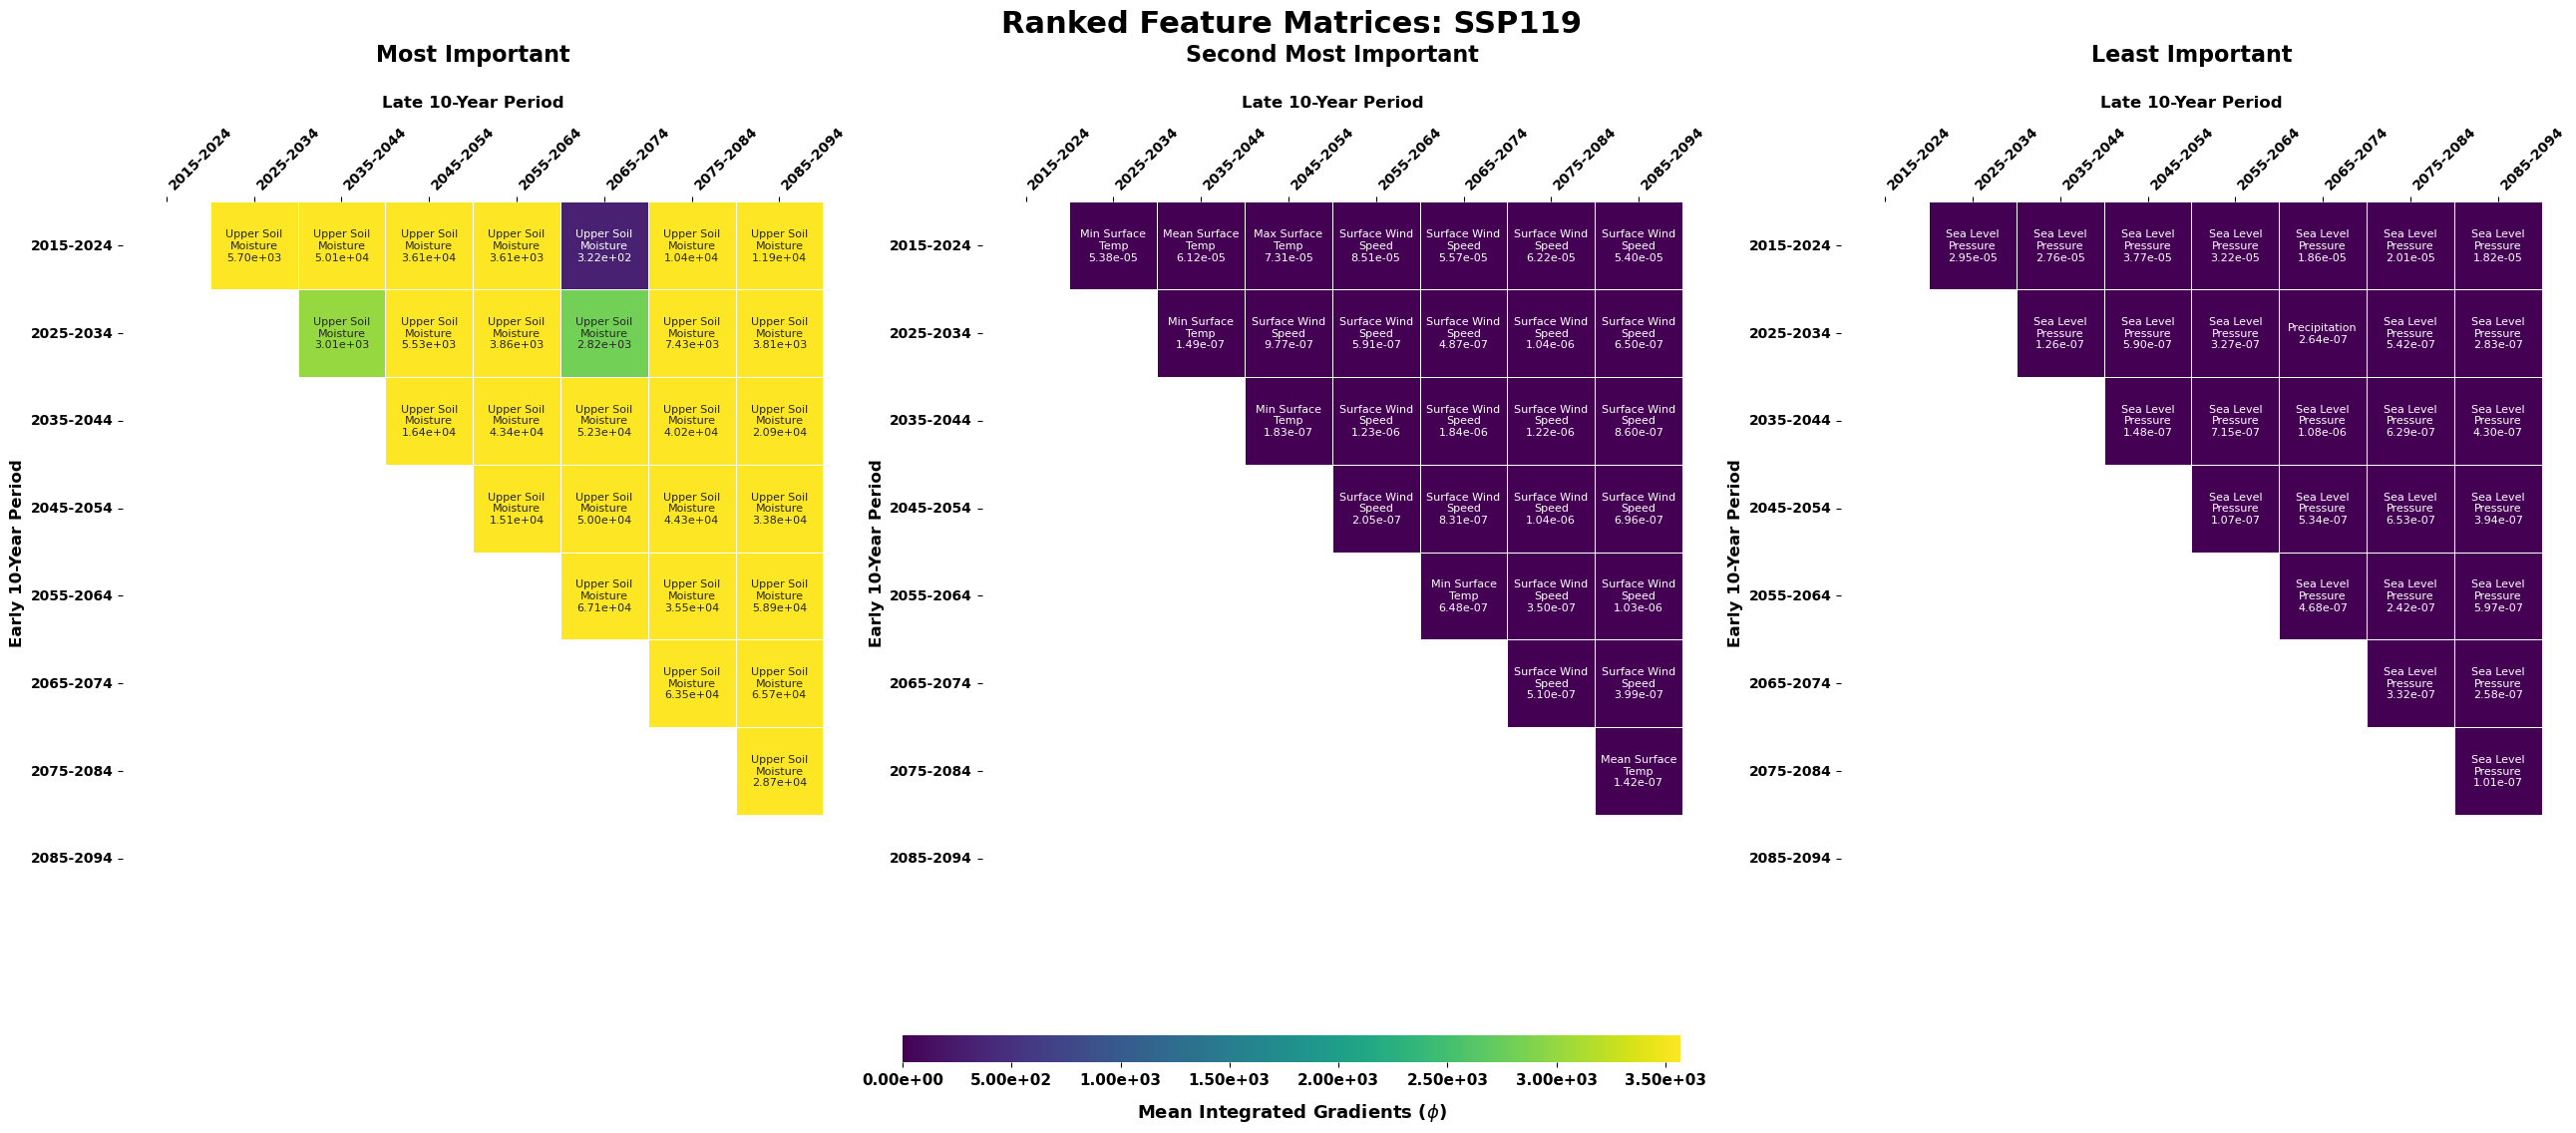

In [44]:
plot_ranked_matrices_single_global_scale(
    phi_matrix=master_phi_matrix, 
    yr_combos_df=my_yr_combos_df, 
    var_names=readable_variables,
    scenario_id="ssp119" # Update this to match your specific run
)

In [ ]:


def plot_ranked_matrices_single_row(phi_matrix, yr_combos_df, var_names, scenario_id="ssp119"):
    """
    Plots the Most, Second Most, and Least important variables side-by-side.
    - Scientific notation rounded to 2 decimal places.
    - Scaled down annotation text size to prevent crowding.
    """
    
    # 1. Aggregate to 2D (yr_combos, vars)
    mean_importance = np.nanmean(np.abs(phi_matrix), axis=(0, 2, 3))
    
    # 2. Sort variables by importance AND get their sorted values
    sorted_indices = np.argsort(mean_importance, axis=1)
    sorted_values = np.sort(mean_importance, axis=1)
    
    # Define the rankings to loop through
    rank_keys = ["Most Important", "Second Most Important", "Least Important"]
    rank_data = [
        (sorted_indices[:, -1], sorted_values[:, -1]), 
        (sorted_indices[:, -2], sorted_values[:, -2]), 
        (sorted_indices[:, 0],  sorted_values[:, 0])   
    ]
    
    # Pre-calculate the matrix grid structure
    all_years = sorted(list(set(yr_combos_df['early'].unique()) | set(yr_combos_df['late'].unique())))
    labels = [f"{int(y)}-{int(y)+9}" for y in all_years]
    
    # --- PLOTTING SETUP ---
    fig, axes = plt.subplots(1, 3, figsize=(26, 10))
    
    for i, rank_title in enumerate(rank_keys):
        rank_indices, rank_values = rank_data[i]
        ax = axes[i]
        
        current_vmin = np.nanmin(rank_values)
        current_vmax = np.nanmax(rank_values)
        
        # --- UPDATE 1: Rounded to 2 decimal places (:.2e) ---
        combined_labels = [
            f"{var_names[idx]}\n{val:.2e}" 
            for idx, val in zip(rank_indices, rank_values)
        ]
        
        df = yr_combos_df.copy()
        df['importance_val'] = rank_values  
        df['text_label'] = combined_labels  
        
        color_matrix = df.pivot_table(index='early', columns='late', values='importance_val', aggfunc='first')
        color_matrix = color_matrix.reindex(index=all_years, columns=all_years)
        
        text_matrix = df.pivot_table(index='early', columns='late', values='text_label', aggfunc='first')
        text_matrix = text_matrix.reindex(index=all_years, columns=all_years).fillna("")
        
        mask = np.tril(np.ones_like(color_matrix, dtype=bool), k=0)
        
        sns.heatmap(
            color_matrix,
            mask=mask,
            cmap='viridis', 
            annot=text_matrix.values, 
            fmt="",                   
            square=True,
            linewidths=.5,
            vmin=current_vmin, 
            vmax=current_vmax,
            ax=ax,
            annot_kws={"size": 8}, # --- UPDATE 2: Scaled down the cell text size ---
            cbar_kws={
                "orientation": "horizontal", 
                "pad": 0.12,                 
                "shrink": 0.85
            } 
        )
        
        colorbar = ax.collections[0].colorbar
        colorbar.ax.xaxis.set_major_formatter(plt.FormatStrFormatter('%.2e'))
        colorbar.ax.tick_params(labelsize=10)
        for tick in colorbar.ax.get_xticklabels():
            tick.set_fontweight('bold')
            
        colorbar.set_label("Mean IG ($\phi$)", fontsize=10, fontweight='bold', labelpad=5)
        
        ax.xaxis.tick_top()
        ax.xaxis.set_label_position('top')
        
        ax.set_xticklabels(labels, rotation=45, ha='left', fontsize=10, fontweight='bold')
        ax.set_yticklabels(labels, rotation=0, fontsize=10, fontweight='bold')
        
        ax.set_xlabel("Late 10-Year Period", fontsize=11, fontweight='bold', labelpad=12)
        ax.set_ylabel("Early 10-Year Period", fontsize=11, fontweight='bold')
        ax.set_title(rank_title, fontsize=15, fontweight='bold', pad=25)
        
    plt.suptitle(f"Ranked Feature Matrices: {scenario_id.upper()}", fontsize=20, fontweight='bold', y=1.02)
    plt.tight_layout()
    plt.show()

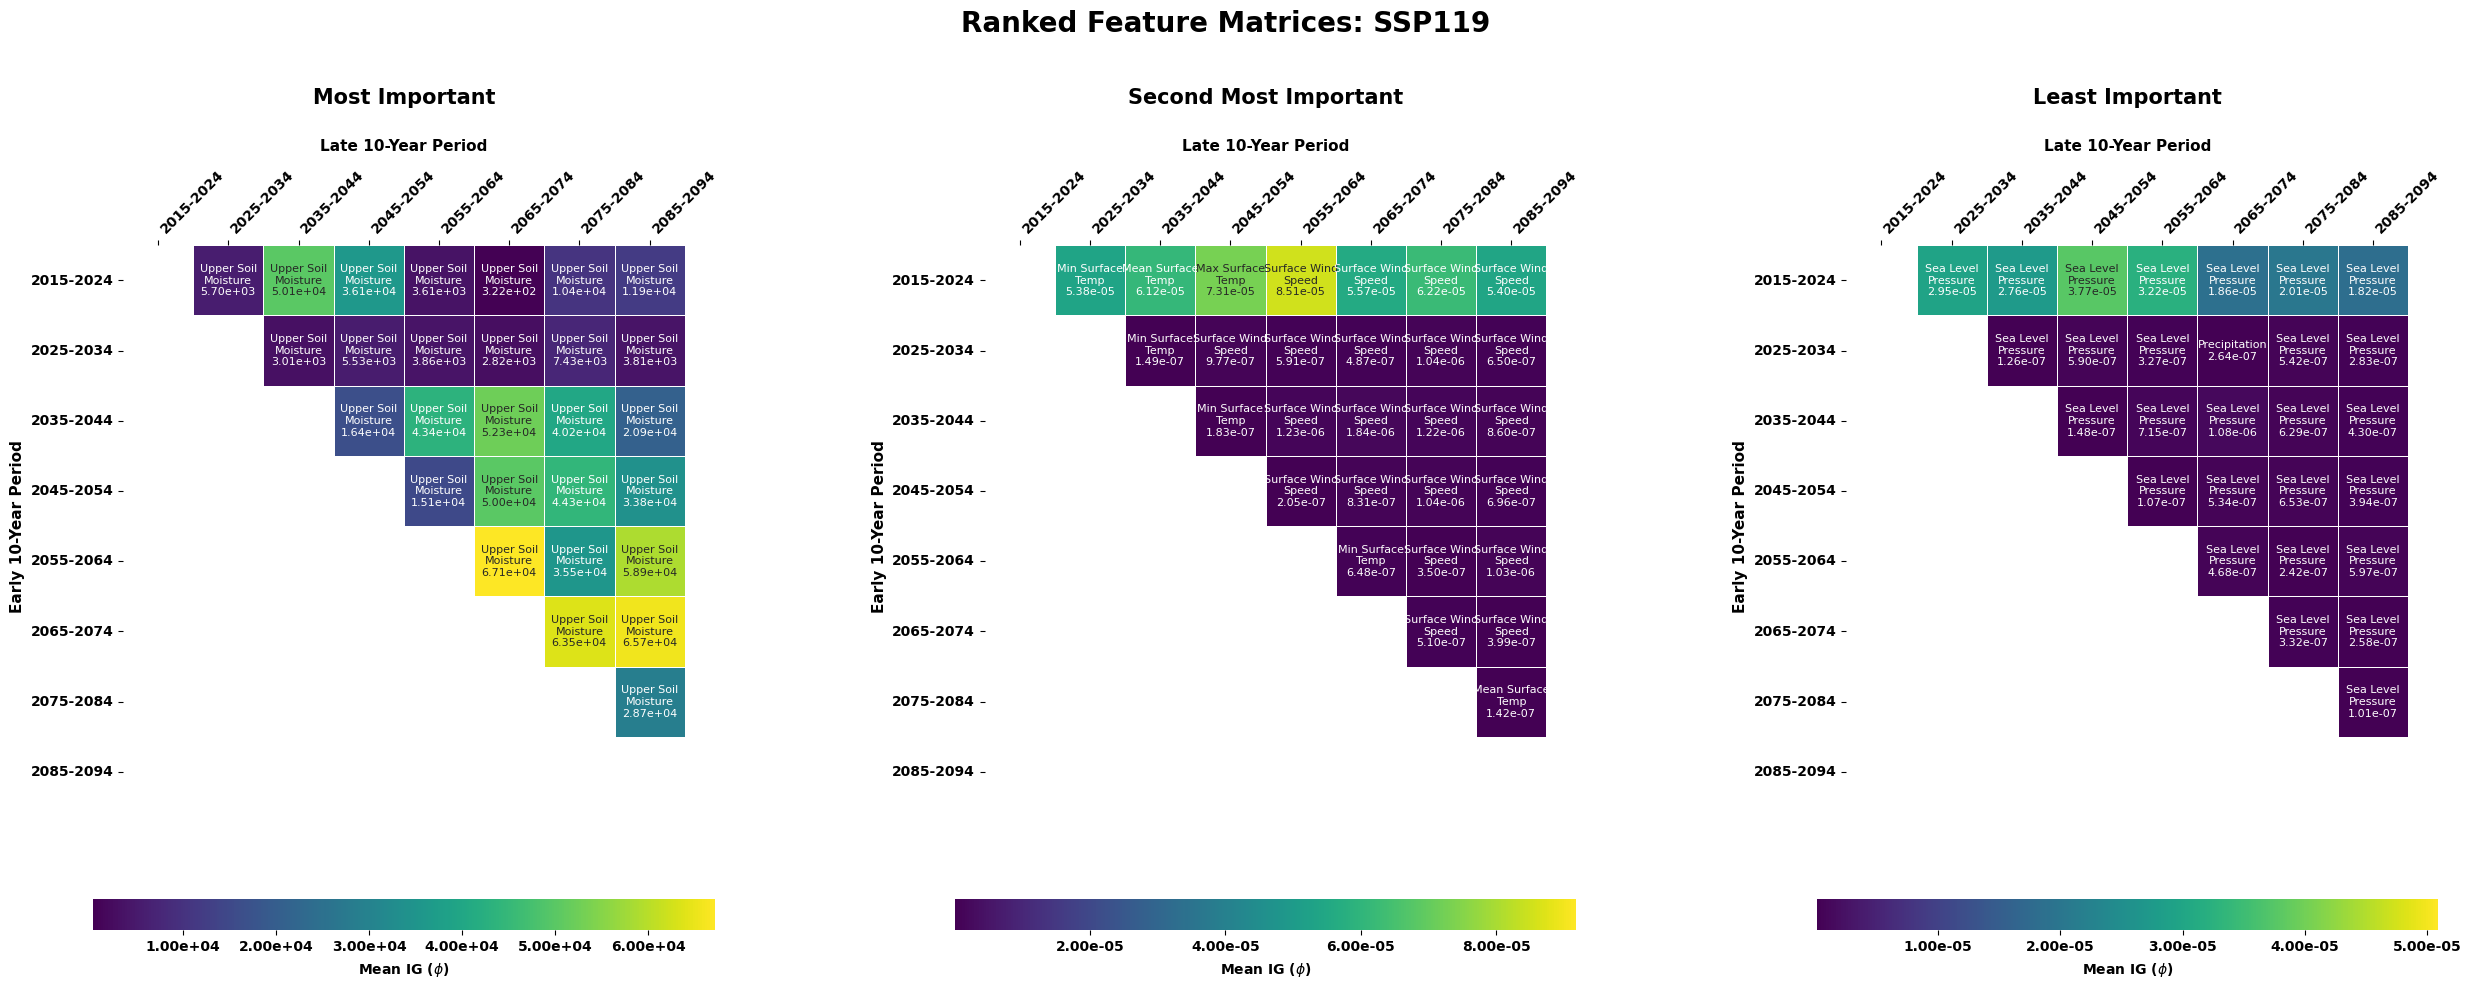

In [45]:
plot_ranked_matrices_single_row(phi_matrix=master_phi_matrix, 
    yr_combos_df=my_yr_combos_df, 
    var_names=readable_variables,
    scenario_id="ssp119")

In [ ]:


def plot_single_combo_bar(phi_matrix, yr_combos_df, early_year, late_year, var_names, scenario_id="ssp119"):
    """
    Extracts a specific year combination from the 5D master matrix and plots a 
    clean, sorted bar chart of variable importance without error bars.
    """
    
    # 1. Look up the index for the requested year combination
    match = yr_combos_df[(yr_combos_df['early'] == early_year) & (yr_combos_df['late'] == late_year)]
    
    if match.empty:
        raise ValueError(f"Error: Could not find a combination for Early: {early_year}, Late: {late_year}")
        
    combo_idx = match.iloc[0]['combo_idx']
    
    # 2. Extract data for this year combo
    combo_data = phi_matrix[:, combo_idx, :, :, :]
    
    # 3. Average across the spatial dimensions (lon and lat)
    spatial_means_per_run = np.nanmean(np.abs(combo_data), axis=(1, 2))
    
    # 4. Convert to a DataFrame and Melt for Seaborn
    df_runs = pd.DataFrame(spatial_means_per_run, columns=var_names)
    df_melted = df_runs.melt(var_name='Variable', value_name='Mean Importance')
    
    # Calculate the overall mean to determine the descending sort order
    mean_order = df_melted.groupby('Variable')['Mean Importance'].mean().sort_values(ascending=False)
    order = mean_order.index
    
    # --- PLOTTING ---
    plt.figure(figsize=(12, 7))
    
    # Create the bar plot (errorbar=None explicitly removes standard deviation lines)
    ax = sns.barplot(
        data=df_melted,
        x='Variable',
        y='Mean Importance',
        order=order,
        palette='viridis',
        edgecolor='black',
        errorbar=None 
    )
    ax.set_yscale("log")
    
    # Add text labels (scientific notation) above each bar
    max_val = mean_order.max()
    buffer = max_val * 0.03 # A small 3% buffer to keep text hovering uniformly
    
    for i, var in enumerate(order):
        val = mean_order[var]
        
       # Multiply by 1.5 to push the text just slightly above the bar on a log scale
        y_pos = val * 1.5 
        
        ax.text(i, y_pos,
                f"{val:.2e}",
                ha='center', va='bottom', fontweight='bold', fontsize=10)
   
    
    # --- FORMATTING ---
    plt.title(f"Variable Importance ({early_year} vs {late_year}) - {scenario_id.upper()}", 
              fontsize=18, fontweight='bold', pad=25)
    plt.xlabel("Climate Variables", fontsize=13, fontweight='bold', labelpad=15)
    plt.ylabel("Mean Integrated Gradients ($\phi$)", fontsize=13, fontweight='bold', labelpad=15)
    
    plt.xticks(fontsize=12, fontweight='bold')
    
    # Format y-axis to scientific notation
    ax.yaxis.set_major_formatter(plt.FormatStrFormatter('%.2e'))
    plt.yticks(fontsize=11, fontweight='bold')
    
    # Dynamically scale the y-axis ceiling based strictly on the highest bar
    plt.ylim(0, max_val * 1.15)
    
    # Remove top and right borders for a cleaner look
    sns.despine()
    
    plt.tight_layout()
    plt.show()

# To call it:
# plot_single_combo_bar_no_errors(master_phi_matrix, my_yr_combos_df, 2035, 2065, my_variables, "ssp119")

/var/folders/v1/c8q_17915_v735dr_k_2fb7w0000gn/T/ipykernel_26949/1418700305.py:38: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(
/var/folders/v1/c8q_17915_v735dr_k_2fb7w0000gn/T/ipykernel_26949/1418700305.py:77: UserWarning: Attempt to set non-positive ylim on a log-scaled axis will be ignored.
  plt.ylim(0, max_val * 1.15)


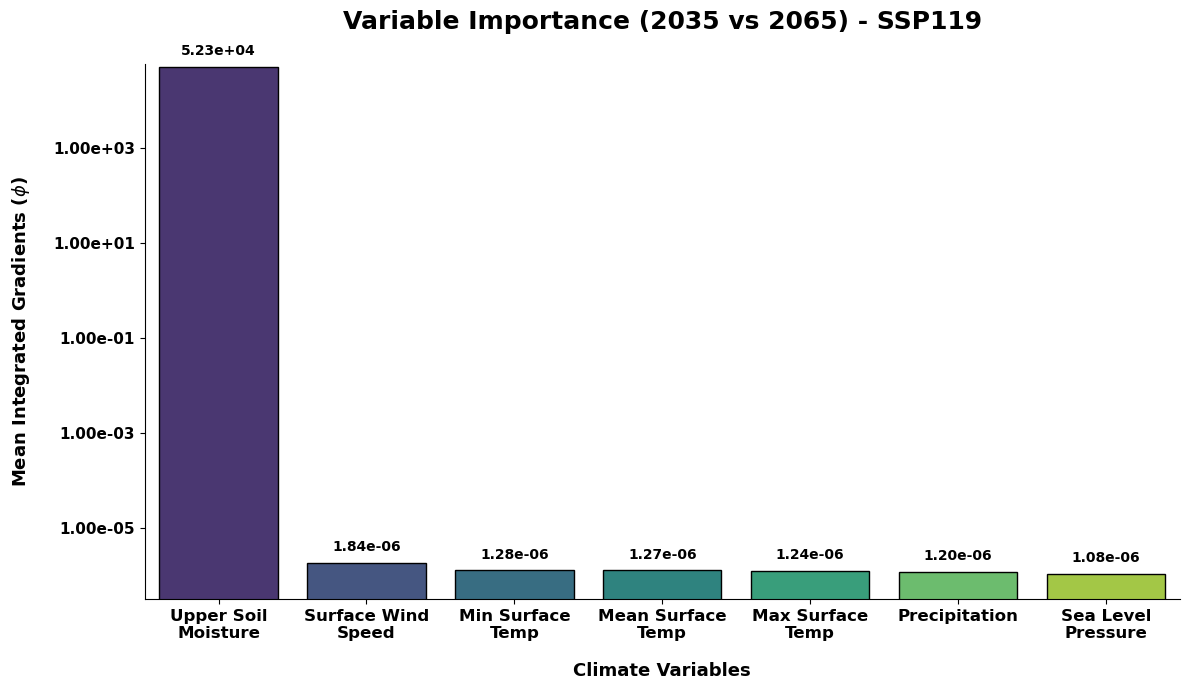

In [46]:
plot_single_combo_bar(
    phi_matrix=master_phi_matrix, 
    yr_combos_df=my_yr_combos_df, 
    early_year=2035,        # The exact early start year
    late_year=2065,         # The exact late start year
    var_names=readable_variables,
    scenario_id="ssp119"
)